# CMIP6 Exploratory Plots — Spatial Warming Visualization

Run this in Google Colab. It produces the six exploratory figures for the checkpoint video.

Question: **How does global warming spread unevenly across the planet from 1850 → 2100, and how does that pattern depend on the emissions scenario we choose?**

Each plot below replaces a corresponding placeholder in the team checkpoint video.

In [10]:
!pip install -q xarray zarr gcsfs cftime nc-time-axis scipy
print('packages ready')

packages ready


In [11]:
import numpy as np
import pandas as pd
import xarray as xr
import gcsfs
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

gcs = gcsfs.GCSFileSystem(token='anon')
df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
print(df.shape, 'rows in catalog')

(523774, 11) rows in catalog


## Step 1 — Pick a model and pull historical + future tas runs

Using CESM2 (NCAR) for historical + 3 SSP scenarios. `tas` = monthly mean near-surface air temperature.
We pick `r1i1p1f1` (the first realization) for consistency.

In [14]:
def open_run(experiment, source='CanESM5', member='r1i1p1f1', table='Amon', var='tas'):
    q = df[
        (df.source_id     == source)     &
        (df.experiment_id == experiment) &
        (df.member_id     == member)     &
        (df.table_id      == table)      &
        (df.variable_id   == var)
    ]
    if q.empty:
        raise ValueError(f'No match for {source}/{experiment}/{var}')
    gn = q[q.grid_label == 'gn']
    row = gn.iloc[0] if not gn.empty else q.iloc[0]
    print(f'  loaded {source}/{experiment}: {row.zstore.split("/")[-4]}')
    return xr.open_zarr(gcs.get_mapper(row.zstore), consolidated=True)

ds_hist = open_run('historical')
ds_585  = open_run('ssp585')
ds_245  = open_run('ssp245')
ds_126  = open_run('ssp126')
print('Historical:', ds_hist.tas.shape)
print('SSP585:    ', ds_585.tas.shape)

  loaded CanESM5/historical: tas
  loaded CanESM5/ssp585: tas


/var/folders/jc/zlyx5cfj47b4kf9kgt678kkc0000gn/T/ipykernel_36676/3236164948.py:14: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  return xr.open_zarr(gcs.get_mapper(row.zstore), consolidated=True)


  loaded CanESM5/ssp245: tas
  loaded CanESM5/ssp126: tas


/var/folders/jc/zlyx5cfj47b4kf9kgt678kkc0000gn/T/ipykernel_36676/3236164948.py:14: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  return xr.open_zarr(gcs.get_mapper(row.zstore), consolidated=True)


Historical: (1980, 64, 128)
SSP585:     (3432, 64, 128)


In [15]:
def global_mean(da):
    lat_name = next(c for c in da.coords if 'lat' in c.lower())
    w = np.cos(np.deg2rad(da[lat_name]))
    w.name = 'weights'
    lon_name = next(c for c in da.coords if 'lon' in c.lower())
    return da.weighted(w).mean([lat_name, lon_name])


## Plot 1 — Global surface air temperature, January 1950

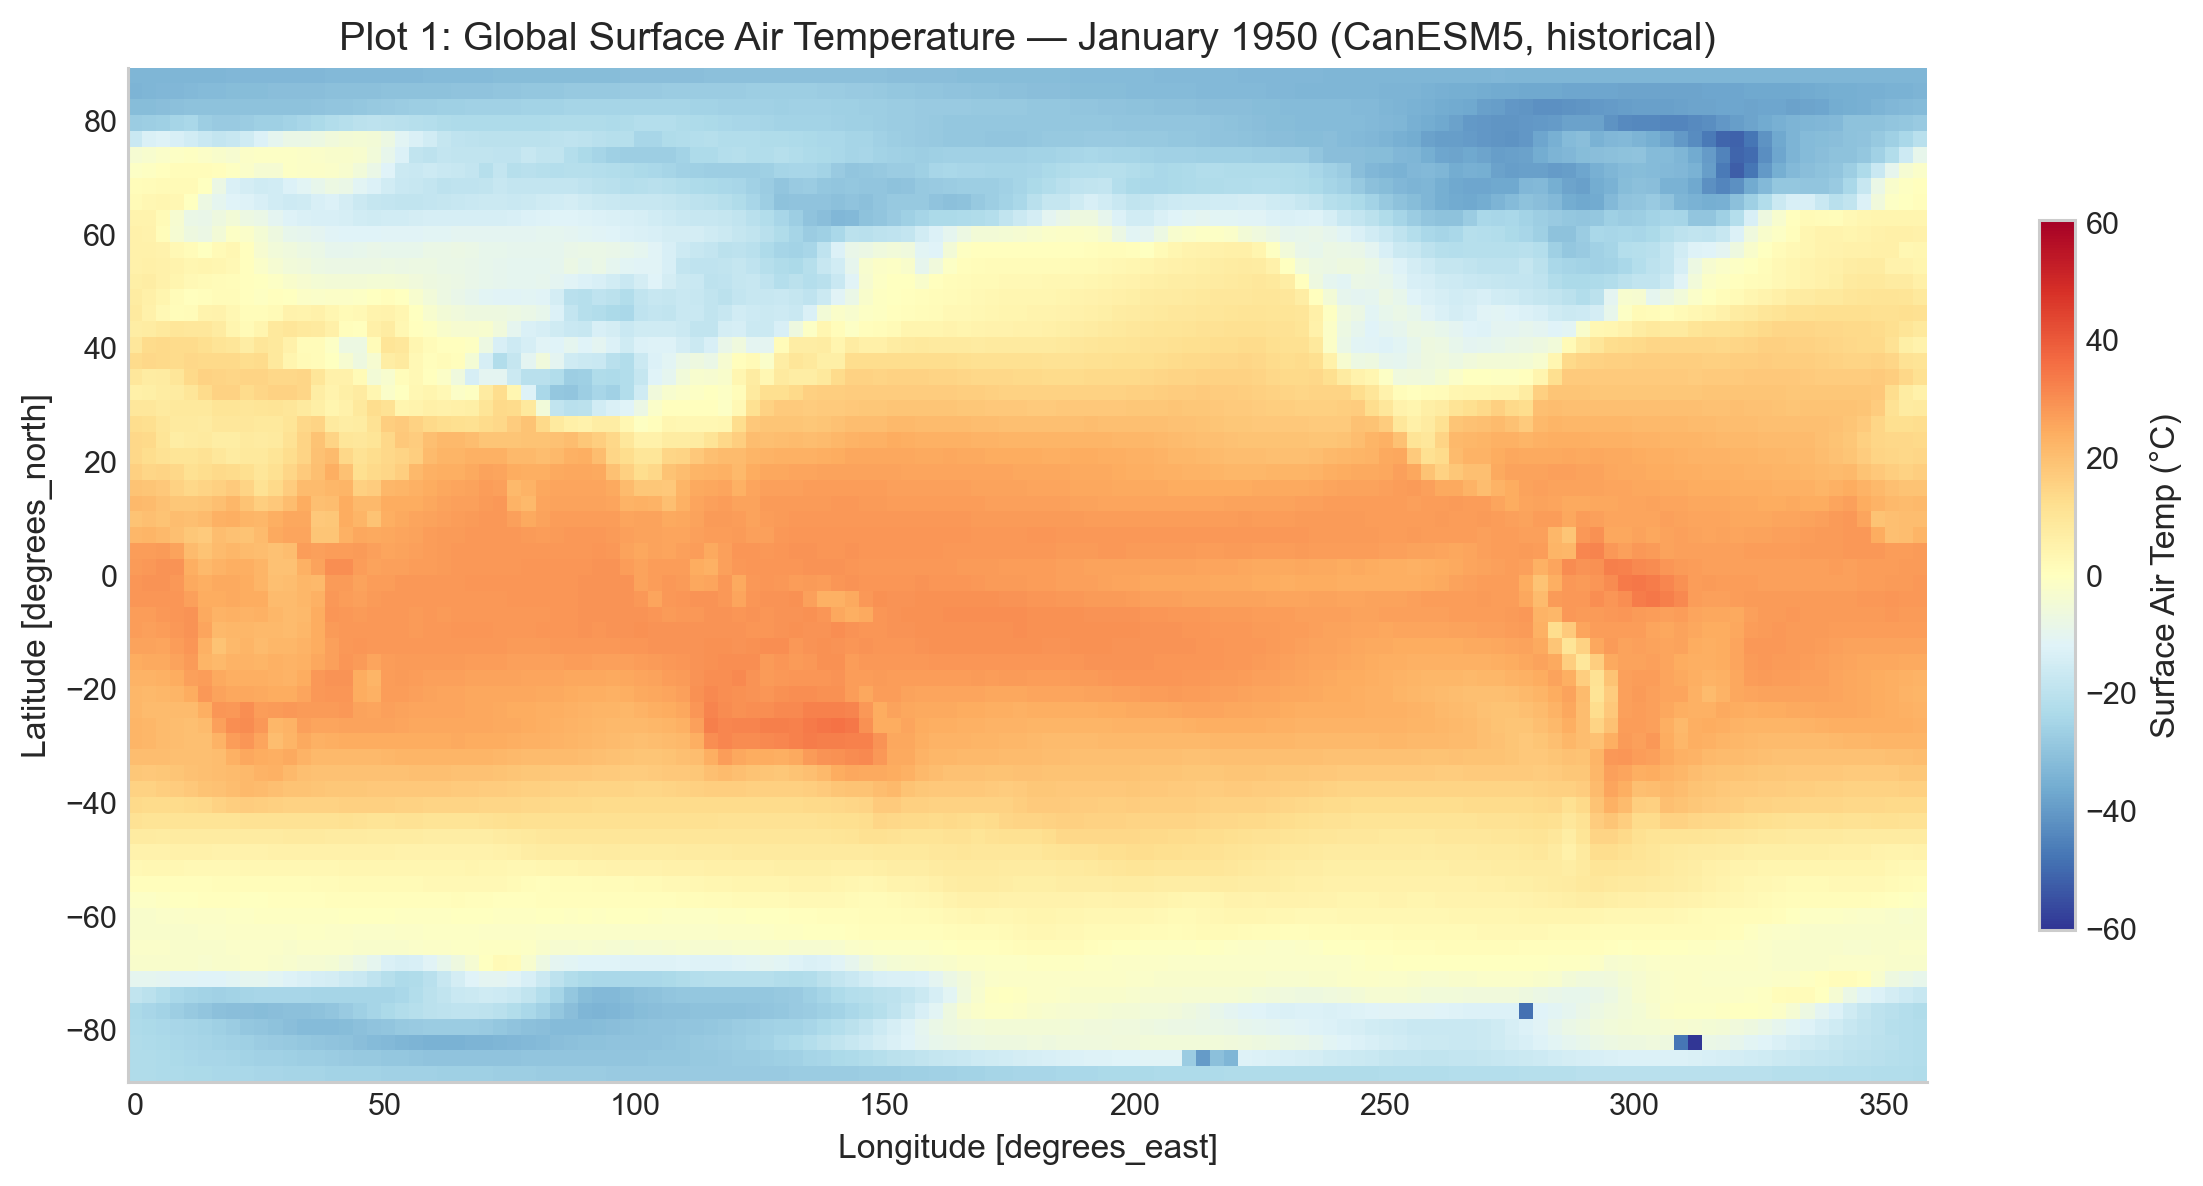

In [16]:
T_1950 = ds_hist.tas.sel(time='1950-01').squeeze() - 273.15

fig, ax = plt.subplots(figsize=(11, 5.5))
T_1950.plot(ax=ax, cmap='RdYlBu_r',
            cbar_kwargs={'label': 'Surface Air Temp (°C)', 'shrink': 0.7})
ax.set_title('Plot 1: Global Surface Air Temperature — January 1950 (CanESM5, historical)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('01_map_1950.png', dpi=120, bbox_inches='tight')
plt.show()

## Plot 2 — Same, but January 2090 under SSP585

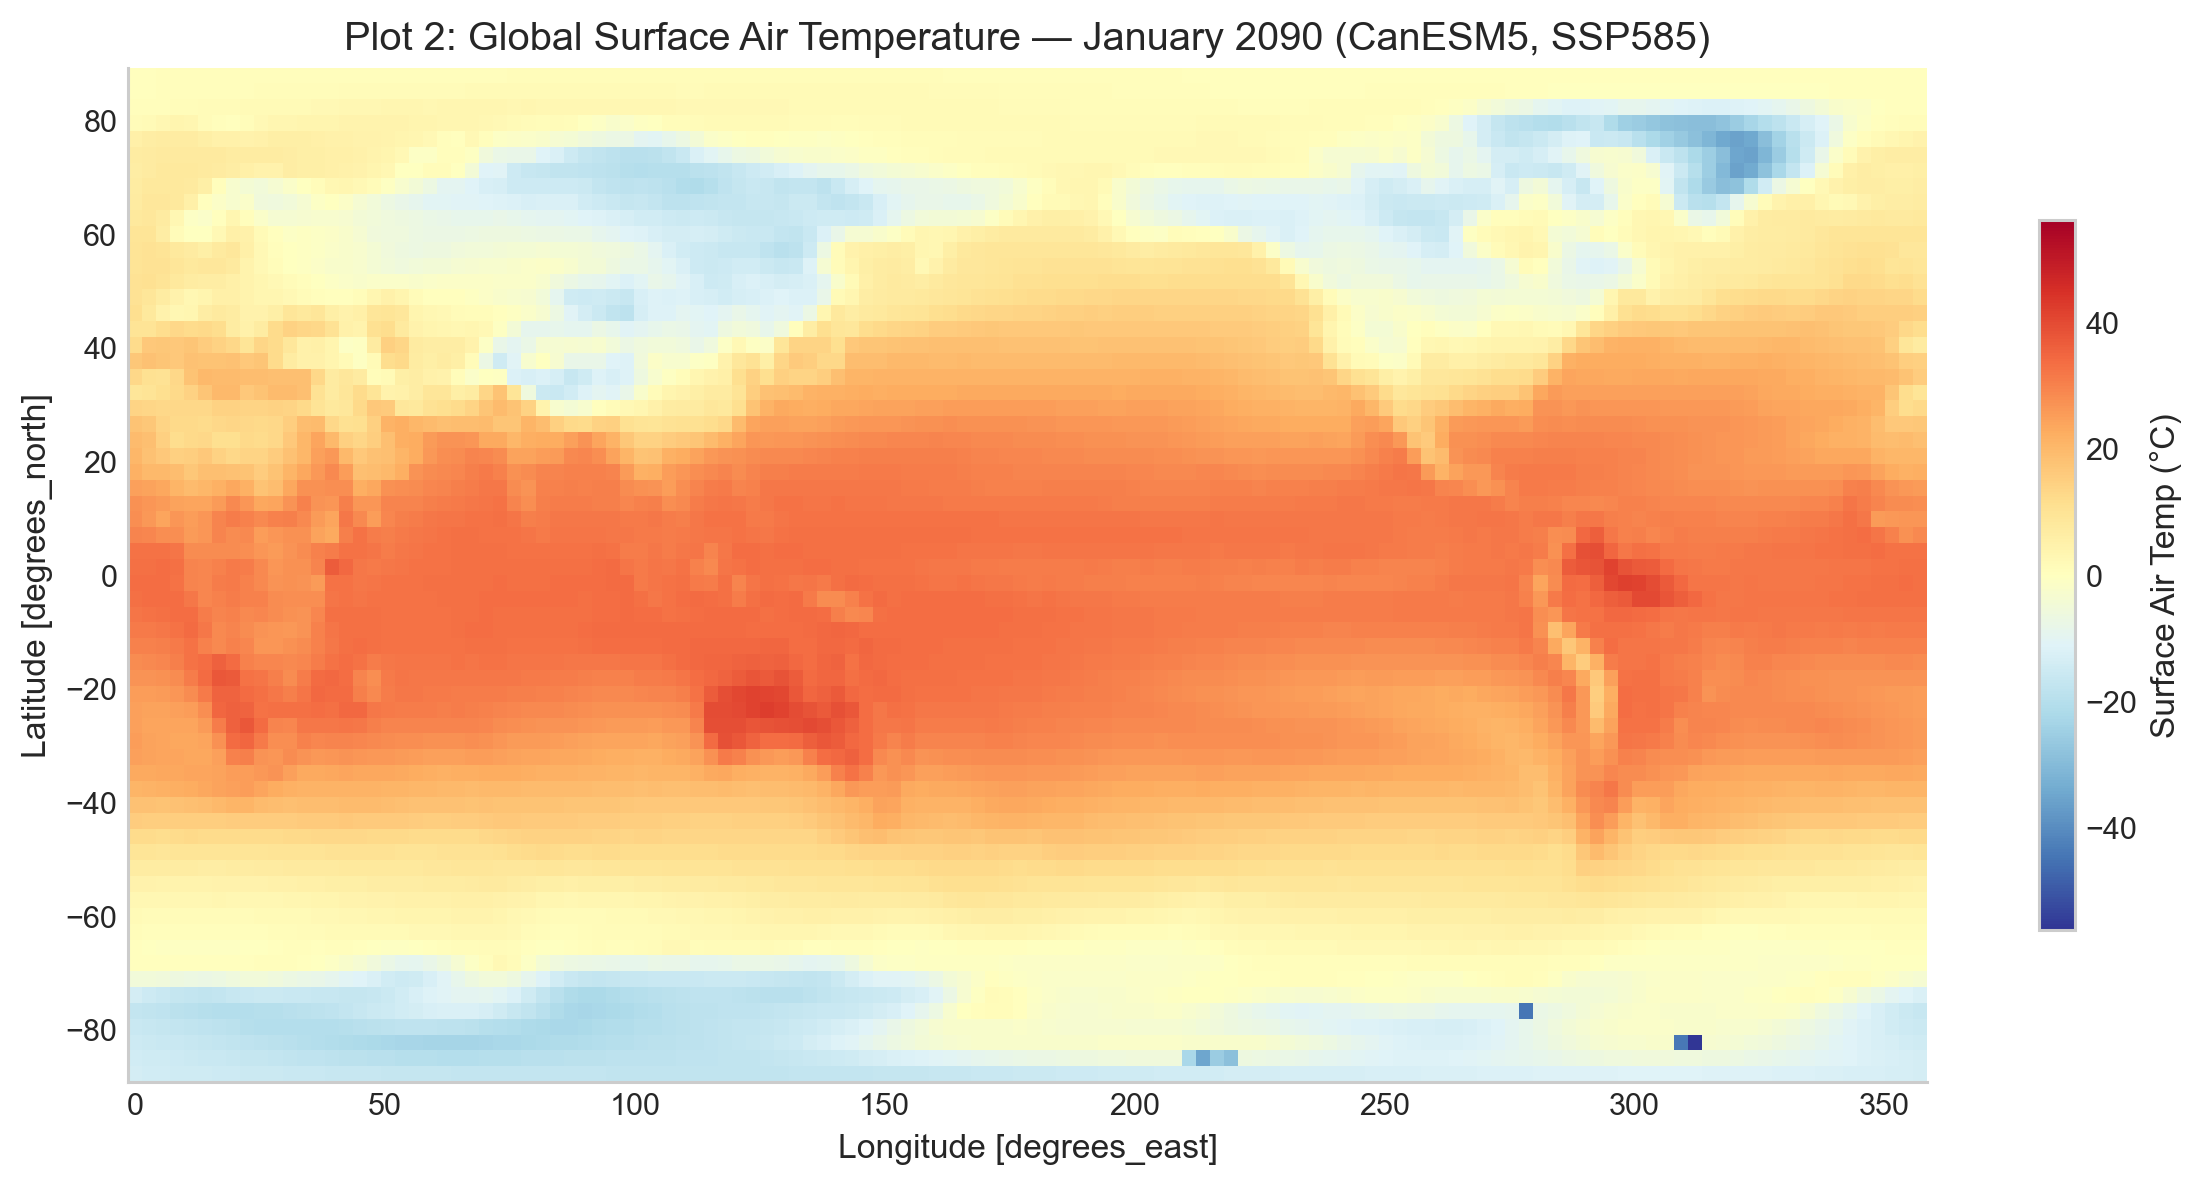

In [17]:
T_2090 = ds_585.tas.sel(time='2090-01').squeeze() - 273.15

fig, ax = plt.subplots(figsize=(11, 5.5))
T_2090.plot(ax=ax, cmap='RdYlBu_r',
            cbar_kwargs={'label': 'Surface Air Temp (°C)', 'shrink': 0.7})
ax.set_title('Plot 2: Global Surface Air Temperature — January 2090 (CanESM5, SSP585)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('02_map_2090.png', dpi=120, bbox_inches='tight')
plt.show()

## Plot 3 — Difference map (the warming pattern)
Average over a decade on each end to suppress weather noise.

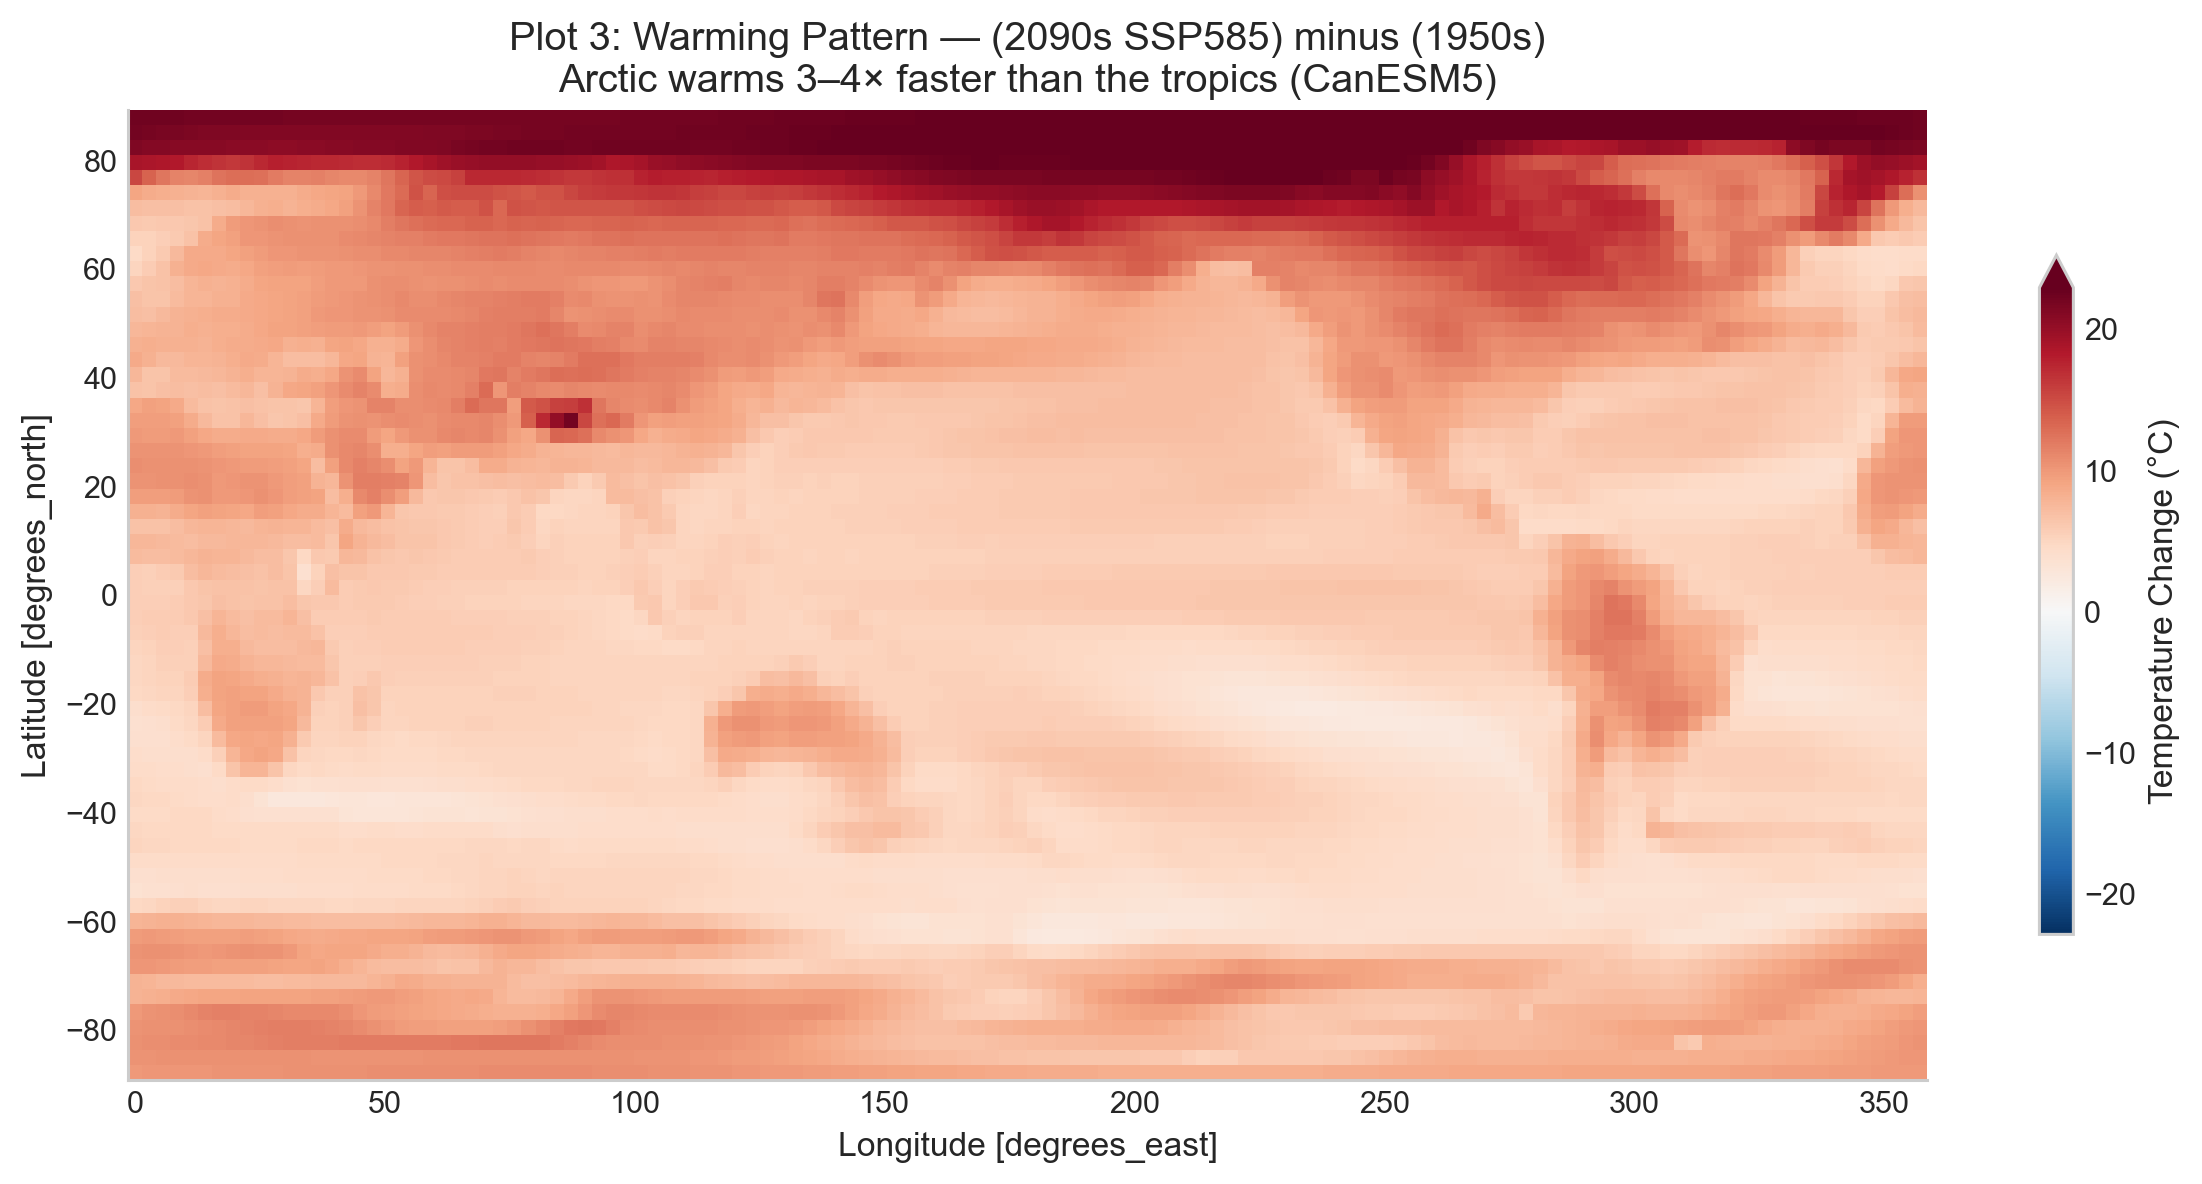

In [18]:
T_early = ds_hist.tas.sel(time=slice('1950-01', '1959-12')).mean('time') - 273.15
T_late  = ds_585.tas.sel(time=slice('2090-01', '2099-12')).mean('time') - 273.15
diff = (T_late - T_early).load()

vmax = float(np.abs(diff).quantile(0.98))
fig, ax = plt.subplots(figsize=(11, 5.5))
diff.plot(ax=ax, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
          cbar_kwargs={'label': 'Temperature Change (°C)', 'shrink': 0.7})
ax.set_title('Plot 3: Warming Pattern — (2090s SSP585) minus (1950s)\n'
             'Arctic warms 3–4× faster than the tropics (CanESM5)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('03_diff_map.png', dpi=120, bbox_inches='tight')
plt.show()

## Plot 4 — Global mean anomaly, historical + 3 scenarios

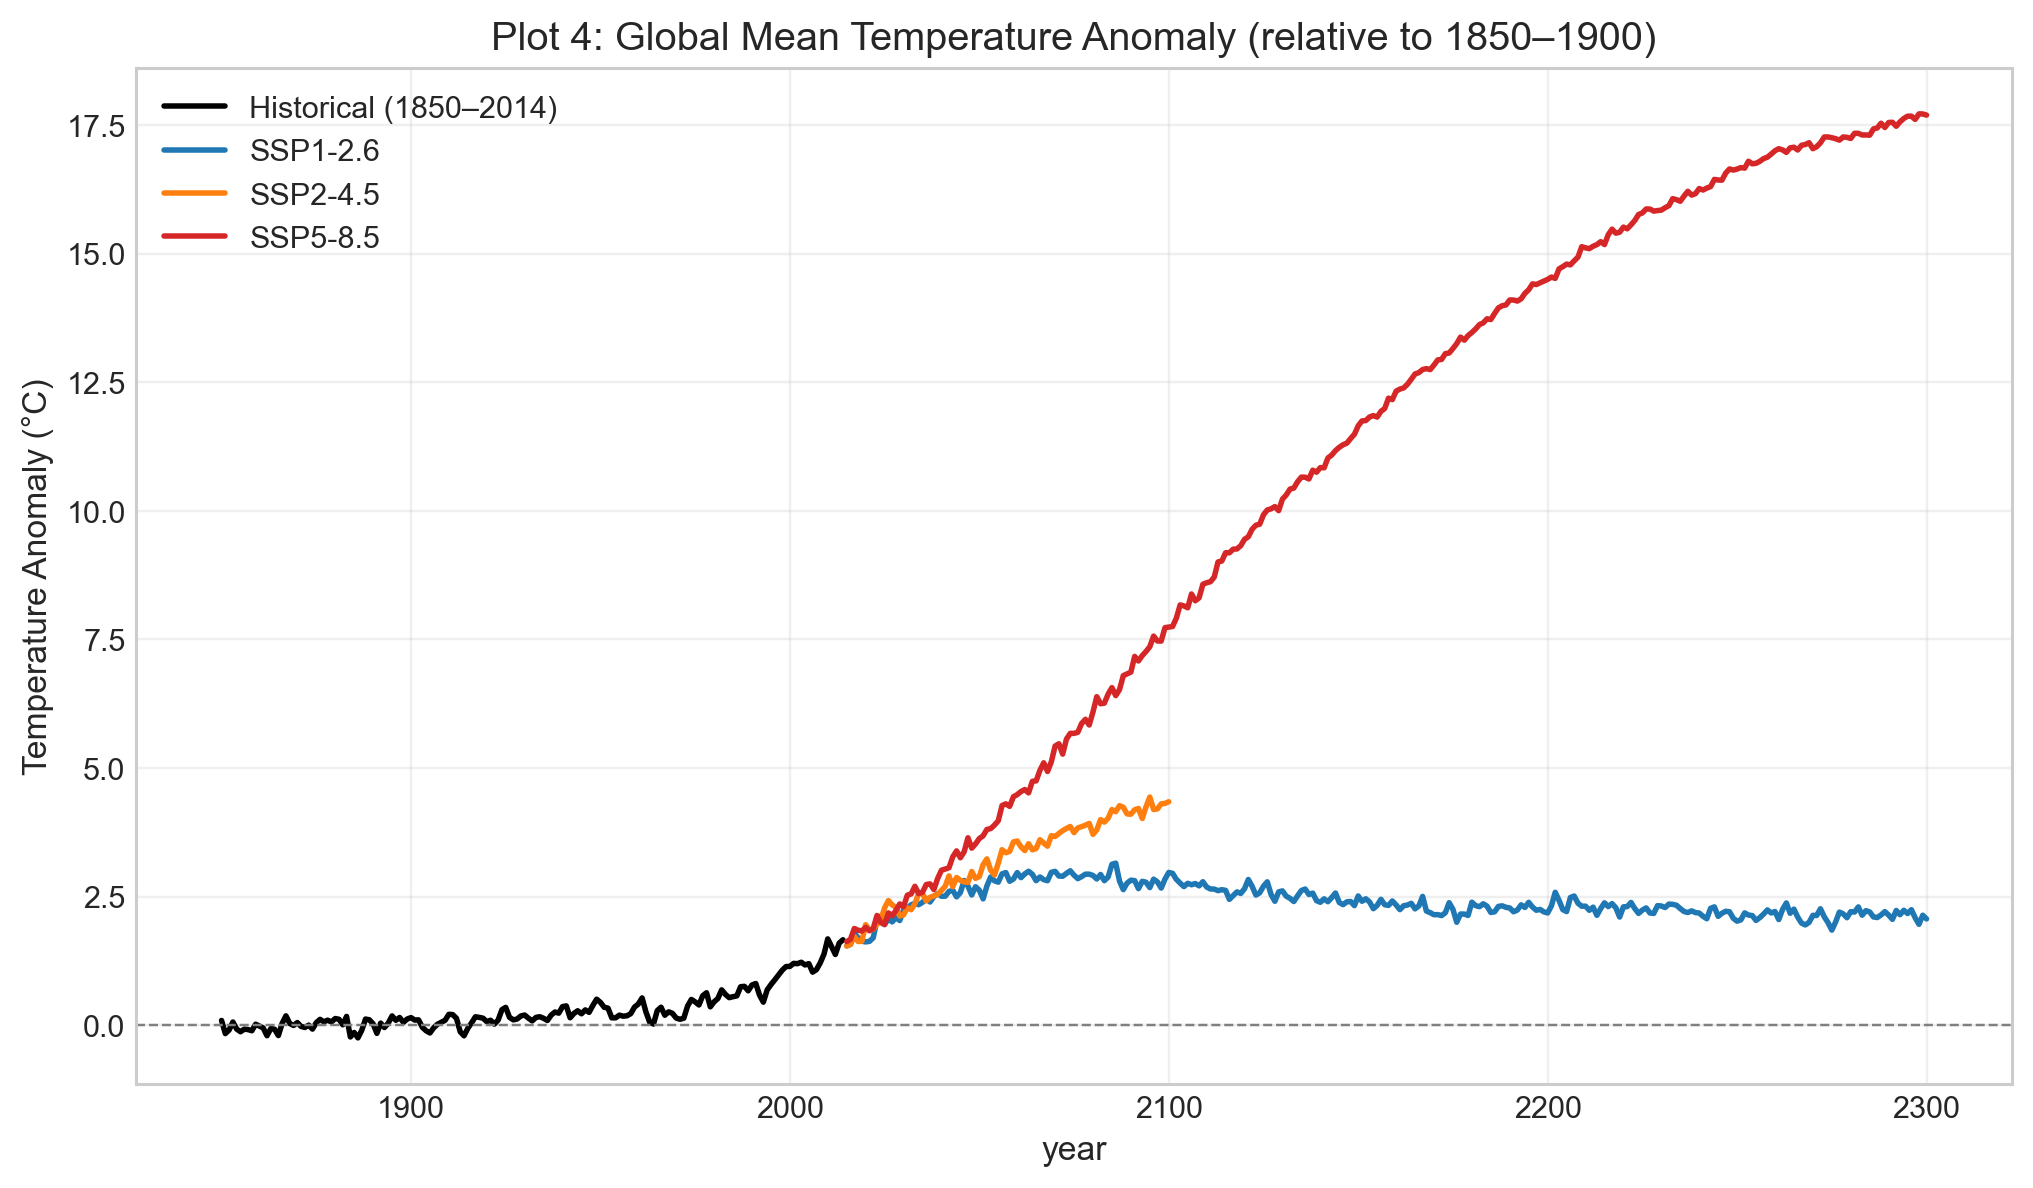

In [19]:
gm_hist = global_mean(ds_hist.tas).load()
gm_126  = global_mean(ds_126.tas).load()
gm_245  = global_mean(ds_245.tas).load()
gm_585  = global_mean(ds_585.tas).load()

baseline = gm_hist.sel(time=slice('1850', '1900')).mean('time')

def annual(x):
    return x.groupby('time.year').mean('time') - baseline

a_hist, a_126, a_245, a_585 = annual(gm_hist), annual(gm_126), annual(gm_245), annual(gm_585)

fig, ax = plt.subplots(figsize=(11, 6))
a_hist.plot(ax=ax, color='black', lw=1.8, label='Historical (1850–2014)')
a_126.plot(ax=ax,  color='#1f77b4', lw=1.8, label='SSP1-2.6')
a_245.plot(ax=ax,  color='#ff7f0e', lw=1.8, label='SSP2-4.5')
a_585.plot(ax=ax,  color='#d62728', lw=1.8, label='SSP5-8.5')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('Temperature Anomaly (°C)')
ax.set_title('Plot 4: Global Mean Temperature Anomaly (relative to 1850–1900)')
ax.legend(); ax.grid(alpha=0.3)
plt.savefig('04_global_timeseries.png', dpi=120, bbox_inches='tight')
plt.show()

## Plot 5 — San Diego time series
Note: CMIP6 longitudes run 0–360, so San Diego (117.16°W) becomes 360−117.16.

In [ ]:
SD_LAT, SD_LON = 32.7157, 360 - 117.1611

def at_point(ds):
    return ds.tas.sel(lon=SD_LON, lat=SD_LAT, method='nearest').load()

sd_hist = at_point(ds_hist).groupby('time.year').mean('time') - 273.15
sd_baseline = sd_hist.sel(year=slice(1850, 1900)).mean('year')
sd_hist_anom = sd_hist - sd_baseline

def sd_anom(ds):
    return at_point(ds).groupby('time.year').mean('time') - 273.15 - sd_baseline

sd_126_anom = sd_anom(ds_126)
sd_245_anom = sd_anom(ds_245)
sd_585_anom = sd_anom(ds_585)

fig, ax = plt.subplots(figsize=(11, 6))
for s, c, lbl in [(sd_hist_anom, 'black', 'Historical'),
                  (sd_126_anom, '#1f77b4', 'SSP1-2.6'),
                  (sd_245_anom, '#ff7f0e', 'SSP2-4.5'),
                  (sd_585_anom, '#d62728', 'SSP5-8.5')]:
    s.rolling(year=10, center=True).mean().plot(ax=ax, color=c, lw=1.8, label=lbl)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('Temperature Anomaly (°C)')
ax.set_title('Plot 5: San Diego Temperature Anomaly (32.7°N, 117.2°W)\n10-year rolling mean')
ax.legend(); ax.grid(alpha=0.3)
plt.savefig('05_san_diego.png', dpi=120, bbox_inches='tight')
plt.show()

## Plot 6 — Multi-model spread, San Diego, SSP585

Pull SSP585 `tas` from several models. Each model has a different climate sensitivity, so the spread captures structural uncertainty.

**Heads up:** this cell is the slowest. ~5–8 models is plenty. Skip any that 404 or have a different grid — they'll throw a KeyError.

In [ ]:
candidate_models = ['CanESM5', 'IPSL-CM6A-LR', 'MPI-ESM1-2-HR',
                     'MIROC6', 'NorESM2-LM', 'ACCESS-CM2',
                     'EC-Earth3', 'CNRM-CM6-1', 'GFDL-ESM4']

# CanESM5 uses 0-360 lon; San Diego at 360-117.16 = 242.84
ensemble = {}
for m in candidate_models:
    try:
        d = open_run('ssp585', source=m)
        lon_name = next(c for c in d.tas.coords if 'lon' in c.lower())
        lat_name = next(c for c in d.tas.coords if 'lat' in c.lower())
        sd_lon_m = SD_LON if d.tas[lon_name].max() > 180 else SD_LON - 360
        ts = d.tas.sel({lon_name: sd_lon_m, lat_name: SD_LAT}, method='nearest')
        ts = ts.groupby('time.year').mean('time') - 273.15
        ensemble[m] = ts.load()
        print(f'  loaded {m}')
    except Exception as e:
        print(f'  skipped {m}: {type(e).__name__}: {e}')

common_years = np.arange(2015, 2101)
stack = []
for m, ts in ensemble.items():
    aligned = ts.reindex(year=common_years)
    stack.append(aligned.values - sd_baseline.values)
stack = np.array(stack)
print('ensemble shape:', stack.shape)

In [ ]:
p10 = np.nanpercentile(stack, 10, axis=0)
p50 = np.nanpercentile(stack, 50, axis=0)
p90 = np.nanpercentile(stack, 90, axis=0)

fig, ax = plt.subplots(figsize=(11, 6))
for row in stack:
    ax.plot(common_years, row, color='#d62728', alpha=0.18, lw=0.8)
ax.fill_between(common_years, p10, p90, color='#d62728', alpha=0.25, label='10–90th percentile')
ax.plot(common_years, p50, color='#d62728', lw=2.5, label='Multi-model median')
sd_hist_anom.rolling(year=10, center=True).mean().plot(ax=ax, color='black', lw=1.5, label='Historical (CESM2)')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title(f'Plot 6: Multi-Model Spread for San Diego under SSP5-8.5 ({stack.shape[0]} models)')
ax.set_ylabel('Temperature Anomaly (°C)')
ax.legend(); ax.grid(alpha=0.3)
plt.savefig('06_model_spread.png', dpi=120, bbox_inches='tight')
plt.show()

## Export a JSON for the D3 viz

For the final visualization, the global gridded data is too big to ship to the browser raw. Downsample to a coarser grid and a decadal time step before exporting.

In [ ]:
import json

def decadal_field(ds, decades, scenario_name):
    """Mean over each decade, then coarsen 4x in lat/lon for browser-friendly size."""
    out = []
    for d in decades:
        f = ds.tas.sel(time=slice(f'{d}-01', f'{d+9}-12')).mean('time') - 273.15
        f = f.coarsen(lat=4, lon=4, boundary='trim').mean()
        out.append({'decade': d, 'data': f.values.round(2).tolist()})
    return {
        'scenario': scenario_name,
        'lat': f.lat.values.round(2).tolist(),
        'lon': f.lon.values.round(2).tolist(),
        'frames': out
    }

hist_decades = list(range(1850, 2010, 10))
fut_decades  = list(range(2020, 2100, 10))

export = {
    'historical': decadal_field(ds_hist, hist_decades, 'historical'),
    'ssp126':     decadal_field(ds_126,  fut_decades, 'ssp126'),
    'ssp245':     decadal_field(ds_245,  fut_decades, 'ssp245'),
    'ssp585':     decadal_field(ds_585,  fut_decades, 'ssp585'),
}

with open('cmip6_decadal.json', 'w') as f:
    json.dump(export, f)
print('wrote cmip6_decadal.json')

---
## Export siconc (Sea Ice Concentration) for D3 Viz

Fetch CanESM5 sea ice concentration (`siconc`) for historical + SSP1-2.6 / SSP2-4.5 / SSP5-8.5,
then regrid to the same 48×72 grid and add to `cmip6_data.json`.

In [1]:
import json, warnings
import numpy as np, pandas as pd, xarray as xr, gcsfs, os
from scipy.spatial import KDTree
warnings.filterwarnings('ignore')

# ── Connect to Google Cloud (catalog already loaded as df / gcs above) ────────
# If running this cell standalone, uncomment the next two lines:
# gcs = gcsfs.GCSFileSystem(token='anon')
# df  = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')

def open_siconc(experiment):
    q = (f"source_id == 'CanESM5' & experiment_id == '{experiment}' "
         "& member_id == 'r1i1p1f1' & table_id == 'SImon' & variable_id == 'siconc'")
    ds = xr.open_zarr(gcs.get_mapper(df.query(q).iloc[0].zstore), consolidated=True)
    print(f'  {experiment}: {str(ds.time.values[0])[:7]} -> {str(ds.time.values[-1])[:7]}')
    return ds

print('Opening siconc datasets (CanESM5 SImon)...')
ds_ice_hist = open_siconc('historical')
ds_ice_126  = open_siconc('ssp126')
ds_ice_245  = open_siconc('ssp245')
ds_ice_585  = open_siconc('ssp585')

# ── Load target grid ───────────────────────────────────────────────────────────
with open('cmip6_data.json') as f:
    DATA = json.load(f)
TARGET_LAT   = np.array(DATA['meta']['lat'])   # 48 S->N
TARGET_LON   = np.array(DATA['meta']['lon'])   # 72 -180->180
DECADES_HIST = DATA['meta']['decades_hist']
DECADES_FUT  = DATA['meta']['decades_fut']

# ── Scale factor (CanESM5 stores siconc in %, values 0-100) ───────────────────
sample = float(ds_ice_hist['siconc'].isel(time=0).mean().values)
SCALE  = 1.0 if sample > 1.5 else 100.0
print(f'  scale factor: {SCALE}')

# ── KD-tree: curvilinear (j,i) grid -> rectilinear target grid ────────────────
flat_lat = ds_ice_hist['latitude'].values.ravel()
flat_lon = np.where(ds_ice_hist['longitude'].values.ravel() > 180,
                    ds_ice_hist['longitude'].values.ravel() - 360,
                    ds_ice_hist['longitude'].values.ravel())
tree = KDTree(np.column_stack([flat_lat, flat_lon]))
tlon_g, tlat_g = np.meshgrid(TARGET_LON, TARGET_LAT)
_, nn_idx = tree.query(np.column_stack([tlat_g.ravel(), tlon_g.ravel()]))
print(f'  KD-tree ready ({len(flat_lat):,} source pts -> {len(nn_idx)} target pts)')

def regrid_flat(arr2d):
    flat = arr2d.ravel()
    out  = flat[nn_idx].reshape(len(TARGET_LAT), len(TARGET_LON))
    out  = np.where(np.isnan(out), 0.0, out * SCALE)
    return np.clip(out, 0, 100)

def make_ice_fields(ds, decades):
    da = ds['siconc']
    fields = {}
    for dec in decades:
        chunk = da.sel(time=slice(f'{dec}-01', f'{dec+9}-12'))
        if chunk.time.size == 0:
            fields[str(dec)] = None; continue
        out = regrid_flat(chunk.mean(dim='time').values)
        fields[str(dec)] = [[round(float(v), 1) for v in row] for row in out]
        print(f'    {dec}: max={out.max():.1f}%  ice_cells={len(out[out>0])}')
    return fields

print('\nHistorical decadal fields...')
hist_ice = make_ice_fields(ds_ice_hist, DECADES_HIST)
print('ssp126...'); fut_126 = make_ice_fields(ds_ice_126, DECADES_FUT)
print('ssp245...'); fut_245 = make_ice_fields(ds_ice_245, DECADES_FUT)
print('ssp585...'); fut_585 = make_ice_fields(ds_ice_585, DECADES_FUT)

def arctic_series(ds):
    da     = ds['siconc']
    lat2d  = ds['latitude'].values
    arctic = da.where(xr.DataArray(lat2d, dims=['j','i']) > 50)
    w      = xr.DataArray(np.cos(np.deg2rad(lat2d)), dims=['j','i'])
    w.name = 'weights'
    annual = arctic.weighted(w).mean(['j','i']).resample(time='YE').mean()
    return [{'year': int(str(t)[:4]), 'value': round(float(annual.sel(time=t).values)*SCALE, 2)}
            for t in annual.time.values
            if not np.isnan(float(annual.sel(time=t).values))]

print('\nArctic annual mean series...')
gm_hist = arctic_series(ds_ice_hist)
gm_126  = arctic_series(ds_ice_126)
gm_245  = arctic_series(ds_ice_245)
gm_585  = arctic_series(ds_ice_585)
print(f'  hist={len(gm_hist)} ssp126={len(gm_126)} ssp245={len(gm_245)} ssp585={len(gm_585)}')

# ── Inject and save ───────────────────────────────────────────────────────────
DATA['fields']['siconc'] = {'historical':hist_ice,'ssp126':fut_126,'ssp245':fut_245,'ssp585':fut_585}
DATA['global_mean']['siconc'] = {'historical':gm_hist,'ssp126':gm_126,'ssp245':gm_245,'ssp585':gm_585}
DATA['meta']['units']['siconc'] = 'percent_ice_cover'

with open('cmip6_data.json', 'w') as fout:
    json.dump(DATA, fout, separators=(',', ':'))

print(f'\nDone! cmip6_data.json ({os.path.getsize("cmip6_data.json")/1e6:.1f} MB)')